# Forecasting IHSG (Jakarta Composite Index) — Time Series Forecasting Project

Project Forecasting **IHSG (Jakarta Composite Index / `^JKSE`)** menggunakan kombinasi model statistik (Holt-Winters, Prophet) dan model machine learning berbasis fitur (Random Forest, XGBoost). Data harian diagregasi menjadi **mingguan** sebagai basis forecasting.

Struktur notebook mengikuti workflow: Data Collection → Data Understanding → Preprocessing → EDA → Modeling → Evaluation → Forecasting → Deployment.

## 1. Data Collection

Sumber data: **Yahoo Finance**, ticker `^JKSE` (Jakarta Composite Index / IHSG), interval harian, 20 tahun terakhir.

In [ ]:
!pip install -q yfinance pandas prophet xgboost

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from prophet import Prophet

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

%matplotlib inline

In [ ]:
ticker_symbol = "^JKSE"   # ticker IHSG di Yahoo Finance
data = "ishg.csv"
try:
    data_ishg = yf.download(ticker_symbol, period="20y", interval="1d")
    if isinstance(data_ishg.columns, pd.MultiIndex):
        data_ishg.columns = data_ishg.columns.droplevel(1)

    if len(data_ishg) == 0:
        raise ValueError("data yang diunduh kosong")

    data_ishg.to_csv(data)
    print(f"Data berhasil diunduh dan disimpan sebagai '{data}'.")

except Exception as e:
    print(f"Gagal mengunduh data baru ({e}).")
    print(f"Memakai file '{data}' yang sudah tersedia.")

[*********************100%***********************]  1 of 1 completed

Data berhasil diunduh dan disimpan sebagai 'ishg.csv'.


## 2. Data Understanding (EDA Awal)

In [ ]:
df = pd.read_csv(data)
df.head()

,Date,Close,High,Low,Open,Volume
0,2006-07-17,1283.898926,1292.136642,1279.620162,1290.385733,7277000
1,2006-07-18,1286.000000,1294.106618,1281.622119,1288.721818,8857800
2,2006-07-19,1280.446167,1294.522646,1277.553335,1293.748628,5987000
3,2006-07-20,1315.538696,1315.538696,1300.673309,1307.235065,8454100
4,2006-07-21,1314.525879,1314.861803,1302.661350,1302.661350,6490400


In [ ]:
df.shape

(4842, 6)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4842 entries, 0 to 4841
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4842 non-null   object 
 1   Close   4842 non-null   float64
 2   High    4842 non-null   float64
 3   Low     4842 non-null   float64
 4   Open    4842 non-null   float64
 5   Volume  4842 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 227.1+ KB


In [ ]:
print("Missing value per kolom:")
df.isnull().sum()

Missing value per kolom:


,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
print("Jumlah baris duplikat:", df.duplicated().sum())

Jumlah baris duplikat: 0


In [ ]:
df.describe()

,Close,High,Low,Open,Volume
count,4842.000000,4842.000000,4842.000000,4842.000000,4.842000e+03
mean,4962.698664,4991.753896,4931.459191,4964.204231,1.066452e+08
std,1818.485725,1827.838855,1811.806091,1821.690382,2.735867e+08
min,1111.346802,1131.714052,1089.297610,1119.072454,0.000000e+00
25%,3778.414856,3791.754425,3739.373788,3776.030869,3.331148e+07
50%,5143.970947,5167.778498,5123.071614,5141.637592,5.386560e+07
75%,6390.337158,6433.161743,6364.936768,6406.437988,1.403525e+08
max,9134.700195,9174.473633,9120.154297,9156.189453,9.788202e+09


## 3. Data Preprocessing

In [ ]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df = df.sort_values('Date').reset_index(drop=True)

Resampling: dari data harian ke mingguan, ambil harga Close di akhir tiap minggu freq='W-FRI' -> setiap minggu ditutup di hari Jumat (hari bursa terakhir dalam seminggu)

In [ ]:
weekly_close = df.groupby(pd.Grouper(key='Date', freq='W-FRI'))['Close'].last()

n_minggu_kosong = weekly_close.isnull().sum()
weekly_close = weekly_close.ffill()

print(f"Jumlah data harian : {len(df)} baris ({df['Date'].min().date()} s/d {df['Date'].max().date()})")
print(f"Jumlah data mingguan: {len(weekly_close)} baris ({n_minggu_kosong} minggu libur penuh di-forward fill)")

Jumlah data harian : 4842 baris (2006-07-17 s/d 2026-07-17)
Jumlah data mingguan: 1044 baris (12 minggu libur penuh di-forward fill)


## 4. Exploratory Data Analysis (EDA)

### 4.1 Grafik Time Series

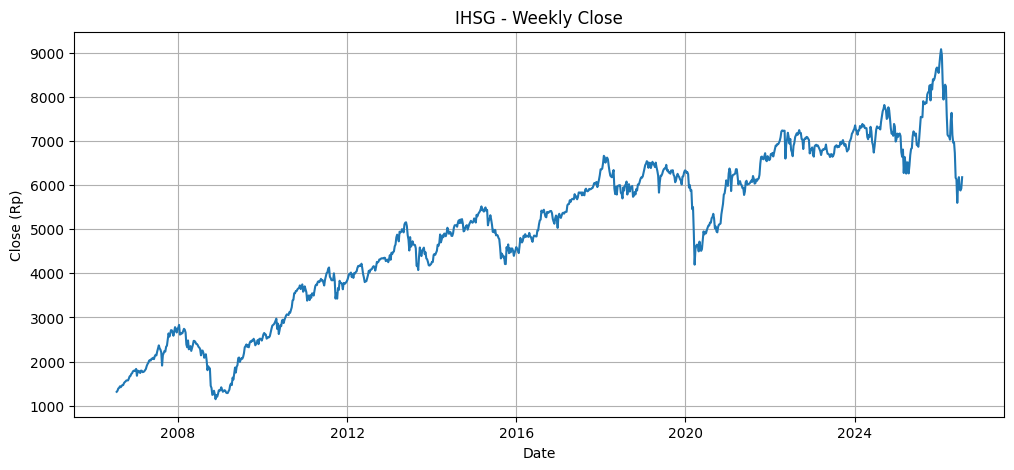

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(weekly_close)
plt.title('IHSG - Weekly Close')
plt.xlabel('Date')
plt.ylabel('Close (Rp)')
plt.grid(True)
plt.show()

### 4.2 Distribusi Data

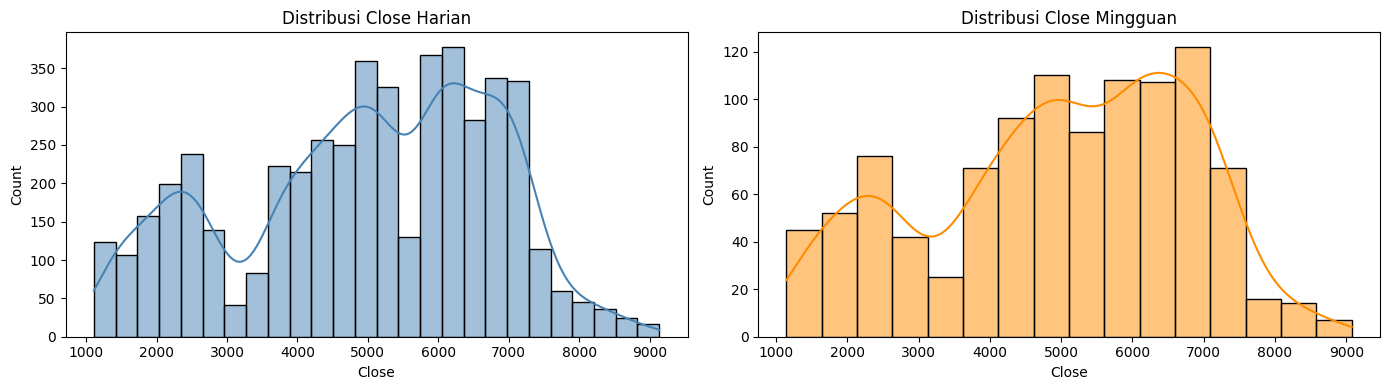

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,4))

sns.histplot(df['Close'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Close Harian')

sns.histplot(weekly_close, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribusi Close Mingguan')

plt.tight_layout()
plt.show()

### 4.3 Rolling Mean & Rolling Standard Deviation

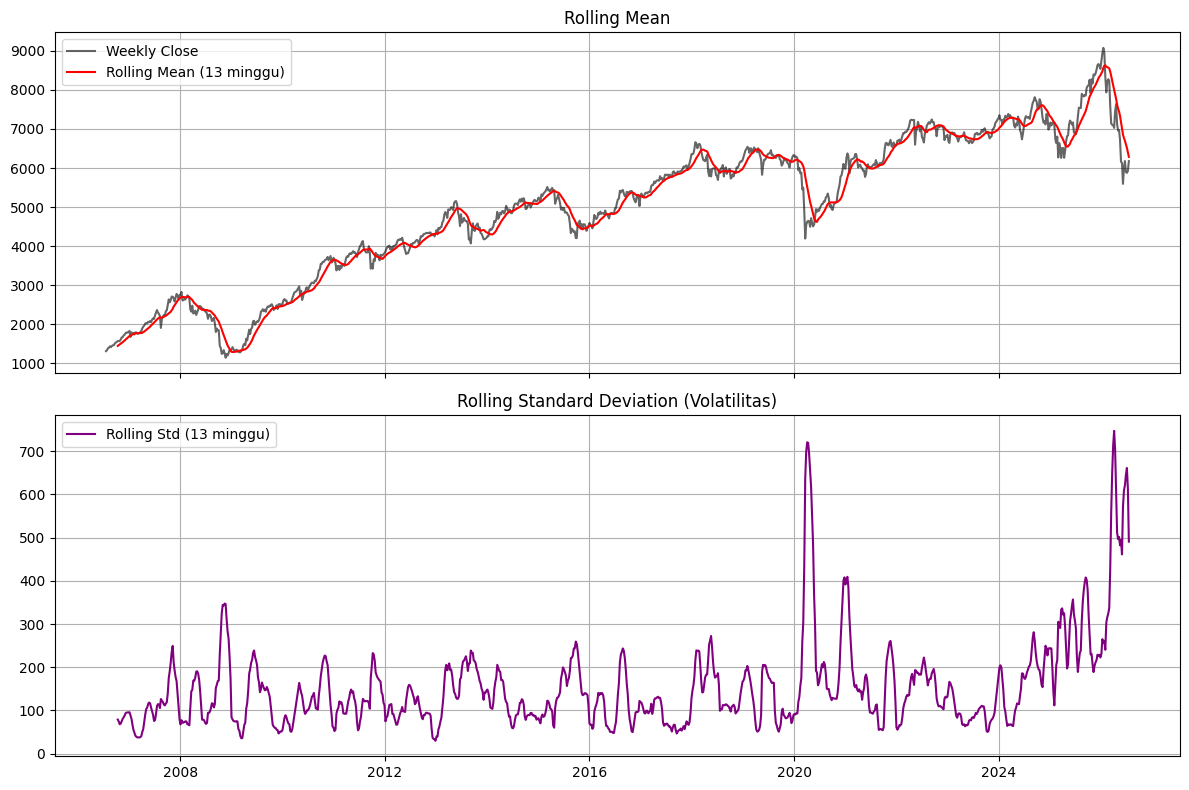

In [ ]:
rolling_mean = weekly_close.rolling(window=13).mean()
rolling_std = weekly_close.rolling(window=13).std()

fig, axes = plt.subplots(2, 1, figsize=(12,8), sharex=True)

axes[0].plot(weekly_close, label='Weekly Close', color='black', alpha=0.6)
axes[0].plot(rolling_mean, label='Rolling Mean (13 minggu)', color='red')
axes[0].set_title('Rolling Mean')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(rolling_std, label='Rolling Std (13 minggu)', color='purple')
axes[1].set_title('Rolling Standard Deviation (Volatilitas)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 4.4 Moving Average (Trend Smoothing)

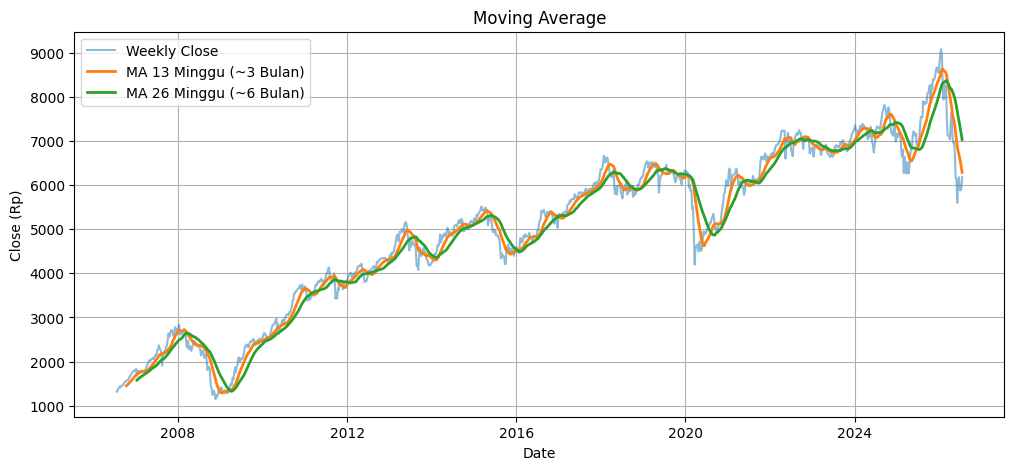

In [ ]:
ma_13 = weekly_close.rolling(window=13).mean()
ma_26 = weekly_close.rolling(window=26).mean()

plt.figure(figsize=(12,5))
plt.plot(weekly_close, label='Weekly Close', alpha=0.5)
plt.plot(ma_13, label='MA 13 Minggu (~3 Bulan)', linewidth=2)
plt.plot(ma_26, label='MA 26 Minggu (~6 Bulan)', linewidth=2)
plt.title('Moving Average')
plt.xlabel('Date')
plt.ylabel('Close (Rp)')
plt.legend()
plt.grid(True)
plt.show()

### 4.5 Analisis Trend & Seasonality (Decomposition)

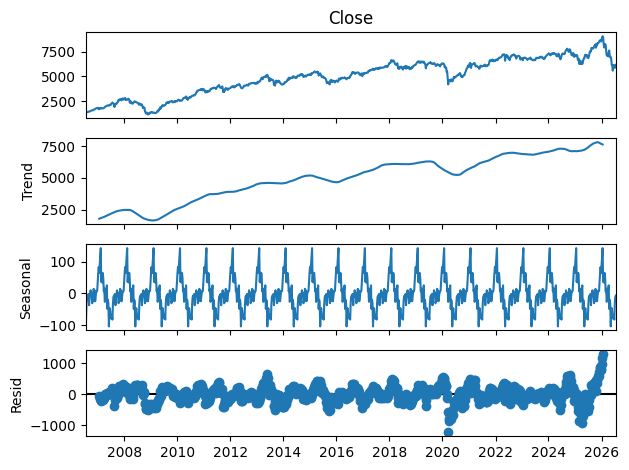

In [ ]:
decomp = seasonal_decompose(
    weekly_close,
    model='additive',
    period=52)
decomp.plot()
plt.show()

## 5. Modeling

Project ini memakai **4 model**: Holt-Winters, Prophet, Random Forest Regression, XGBoost Regression.

In [ ]:
train_size = int(len(weekly_close) * 0.8)
train = weekly_close[:train_size]
test = weekly_close[train_size:]
print(f"Train: {len(train)} minggu, Test: {len(test)} minggu")

Train: 835 minggu, Test: 209 minggu


### 5.1 Holt-Winters Exponential Smoothing

In [ ]:
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=52)
hw_fit = hw_model.fit()
hw_pred = hw_fit.forecast(steps=len(test))

### 5.2 Prophet

In [ ]:
prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(seasonality_mode='multiplicative', seasonality_prior_scale=15, yearly_seasonality=True)
prophet_model.fit(prophet_train)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
future_test = prophet_model.make_future_dataframe(periods=len(test), freq='W-FRI')
forecast_test = prophet_model.predict(future_test)

prophet_pred = forecast_test[['ds', 'yhat']].tail(len(test))
prophet_pred = pd.Series(prophet_pred['yhat'].values, index=test.index)

### 5.3 Feature Engineering untuk Random Forest & XGBoost

Karena Random Forest dan XGBoost bukan model time series murni. Kedua model hanya mengenal data tabular (fitur X → target y), sehingga harus mengubah time series menjadi fitur terlebih dahulu.

In [ ]:
df_ml = pd.DataFrame({'harga': weekly_close})
df_ml['return'] = np.log(df_ml['harga']).diff()

df_ml['lag_1'] = df_ml['return'].shift(1)
df_ml['lag_2'] = df_ml['return'].shift(2)
df_ml['lag_4'] = df_ml['return'].shift(4)
df_ml['rolling_mean_4'] = df_ml['return'].shift(1).rolling(window=4).mean()
df_ml['month'] = df_ml.index.month
df_ml['quarter'] = df_ml.index.quarter
df_ml = df_ml.dropna()

feature_cols = [
    'lag_1', 'lag_2', 'lag_4',
    'rolling_mean_4',
    'month', 'quarter'
]
df_ml.head()

,harga,return,lag_1,lag_2,lag_4,rolling_mean_4,month,quarter
Date,,,,,,,,
2006-08-25,1416.874878,-0.014599,0.025056,0.009198,0.017220,0.022394,8,3
2006-09-01,1444.433838,0.019264,-0.014599,0.025056,0.038103,0.014439,9,3
2006-09-08,1466.518921,0.015174,0.019264,-0.014599,0.009198,0.009730,9,3
2006-09-15,1465.644043,-0.000597,0.015174,0.019264,0.025056,0.011224,9,3
2006-09-22,1510.766113,0.030322,-0.000597,0.015174,-0.014599,0.004810,9,3


In [ ]:
train_cutoff = train.index[-1]

df_ml_train = df_ml[df_ml.index <= train_cutoff]
df_ml_test = df_ml[df_ml.index > train_cutoff]

X_train = df_ml_train[feature_cols]
y_train = df_ml_train['return']

print(f"Data train: {X_train.shape}")
print(f"Jumlah minggu di periode test: {len(df_ml_test)}")

Data train: (830, 6)
Jumlah minggu di periode test: 209


### 5.4 Recursive Walk-Forward Forecasting

In [ ]:
def recursive_forecast_returns(model, last_price, ret_history, n_steps, dates_out, feature_cols):
    ret_hist = list(ret_history)
    price = last_price
    price_preds, ret_preds = [], []

    for tanggal in dates_out:
        lag_1 = ret_hist[-1]
        lag_2 = ret_hist[-2]
        lag_4 = ret_hist[-4]
        rolling_mean_4 = np.mean(ret_hist[-4:])

        X_next = pd.DataFrame([[lag_1, lag_2, lag_4,
                                rolling_mean_4,
                                tanggal.month, tanggal.quarter]],
                              columns=feature_cols)

        ret_hat = model.predict(X_next)[0]
        price = price * np.exp(ret_hat)

        price_preds.append(price)
        ret_preds.append(ret_hat)
        ret_hist.append(ret_hat)

    return pd.Series(price_preds, index=dates_out), pd.Series(ret_preds, index=dates_out)

### 5.5 Random Forest Regression

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42
)
rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=3,
                      n_estimators=500, random_state=42)

In [ ]:
ret_history_train = list(df_ml_train['return'].values[-12:])
last_train_price = train.iloc[-1]

rf_pred, rf_ret_pred = recursive_forecast_returns(
    rf_model, last_train_price, ret_history_train, len(test), test.index, feature_cols)

### 5.6 XGBoost Regression

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred, xgb_ret_pred = recursive_forecast_returns(
    xgb_model, last_train_price, ret_history_train, len(test), test.index, feature_cols)

## 6. Model Evaluation

Metrik yang dipakai: **MAE, RMSE, MAPE**

In [ ]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    return mae, rmse, mape

results = []
results.append(["Holt-Winters", *evaluate(test, hw_pred)])
results.append(["Prophet", *evaluate(test, prophet_pred)])
results.append(["Random Forest", *evaluate(test, rf_pred)])
results.append(["XGBoost", *evaluate(test, xgb_pred)])

results = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "MAPE"])
results = results.sort_values("MAPE").reset_index(drop=True)
results

,Model,MAE,RMSE,MAPE
0,Random Forest,417.872301,605.288230,5.964490
1,XGBoost,433.493812,583.227427,6.083301
2,Holt-Winters,461.494360,694.899265,6.761720
3,Prophet,658.160404,793.836622,8.884760


In [ ]:
best_model = results.iloc[0]
print(f"Model terbaik berdasarkan MAPE terendah: {best_model['Model']} "
      f"(MAE={best_model['MAE']:.2f}, RMSE={best_model['RMSE']:.2f}, MAPE={best_model['MAPE']:.2f}%)")

Model terbaik berdasarkan MAPE terendah: Random Forest (MAE=417.87, RMSE=605.29, MAPE=5.96%)


## 7. Forecasting

In [ ]:
FORECAST_HORIZON = 12

**Refit & forecast Holt-Winters**

In [ ]:
hw_final = ExponentialSmoothing(
    weekly_close, trend='add', seasonal='add', seasonal_periods=52).fit()
hw_future = hw_final.forecast(steps=FORECAST_HORIZON)

**Refit & forecast Prophet**

In [ ]:
prophet_full = weekly_close.reset_index()
prophet_full.columns = ['ds', 'y']

prophet_final = Prophet(
    seasonality_mode='multiplicative',
    seasonality_prior_scale=15,
    yearly_seasonality=True)
prophet_final.fit(prophet_full)

future_full = prophet_final.make_future_dataframe(periods=FORECAST_HORIZON, freq='W-FRI')
forecast_full = prophet_final.predict(future_full)
prophet_future = forecast_full[['ds', 'yhat']].tail(FORECAST_HORIZON).set_index('ds')['yhat']

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


**Refit & forecast Random Forest**

In [ ]:
X_full = df_ml[feature_cols]
y_full = df_ml['return']

rf_final = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42
)

rf_final.fit(X_full, y_full)

RandomForestRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=3,
                      n_estimators=500, random_state=42)

**Refit & forecast XGBoost**

In [ ]:
X_full = df_ml[feature_cols]
y_full = df_ml['return']

xgb_final = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_final.fit(X_full, y_full)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
ret_history_full = list(df_ml['return'].values[-12:])
last_full_price = weekly_close.iloc[-1]
future_dates = pd.date_range(start=weekly_close.index[-1], periods=FORECAST_HORIZON + 1, freq='W-FRI')[1:]

rf_future, rf_future_ret = recursive_forecast_returns(
    rf_final, last_full_price, ret_history_full, FORECAST_HORIZON, future_dates, feature_cols)
rf_future

,0
2026-07-24,6171.771583
2026-07-31,6177.758542
2026-08-07,6185.298401
2026-08-14,6197.003680
2026-08-21,6200.159268
2026-08-28,6204.341991
2026-09-04,6206.761464
2026-09-11,6209.954399
2026-09-18,6211.721457
2026-09-25,6213.489018


In [ ]:
xgb_future, xgb_future_ret = recursive_forecast_returns(
    xgb_final, last_full_price, ret_history_full, FORECAST_HORIZON, future_dates, feature_cols)
xgb_future

,0
2026-07-24,6089.497296
2026-07-31,6050.273410
2026-08-07,6031.507237
2026-08-14,6052.744686
2026-08-21,6081.792580
2026-08-28,6083.967598
2026-09-04,6084.754511
2026-09-11,6067.207345
2026-09-18,6011.253927
2026-09-25,6038.555568


### Visualisasi Forecast per Model (Next 12 Minggu)

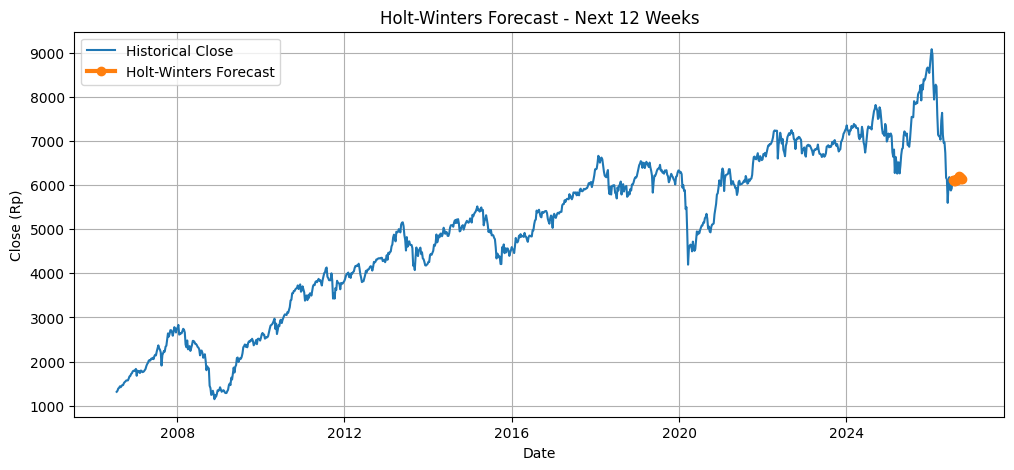

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(weekly_close.index, weekly_close.values, label='Historical Close')
plt.plot(hw_future.index, hw_future.values, marker='o', linewidth=3, label='Holt-Winters Forecast')
plt.title('Holt-Winters Forecast - Next 12 Weeks')
plt.xlabel('Date')
plt.ylabel('Close (Rp)')
plt.legend()
plt.grid(True)
plt.show()

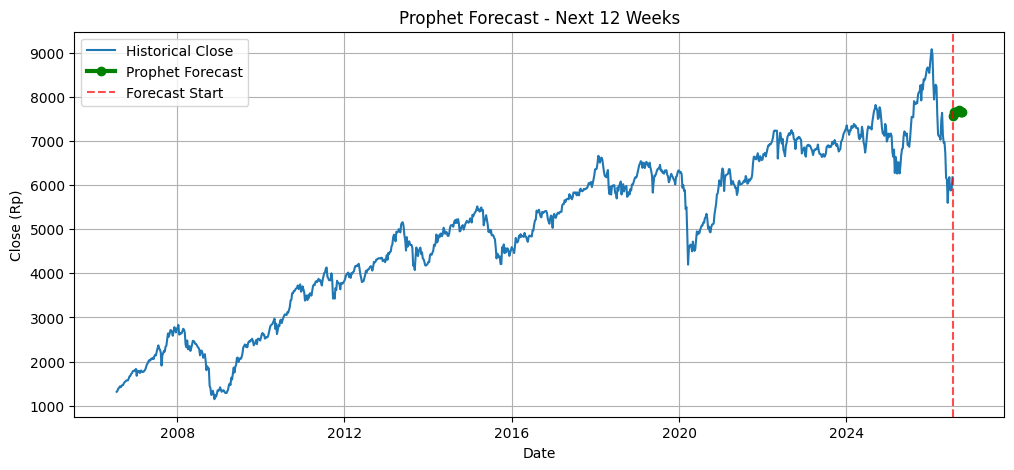

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(weekly_close.index, weekly_close.values, label='Historical Close')
plt.plot(prophet_future.index, prophet_future.values, marker='o', linewidth=3, label='Prophet Forecast', color='green')
plt.axvline(weekly_close.index[-1], color='red', linestyle='--', alpha=0.7, label='Forecast Start')
plt.title('Prophet Forecast - Next 12 Weeks')
plt.xlabel('Date')
plt.ylabel('Close (Rp)')
plt.legend()
plt.grid(True)
plt.show()

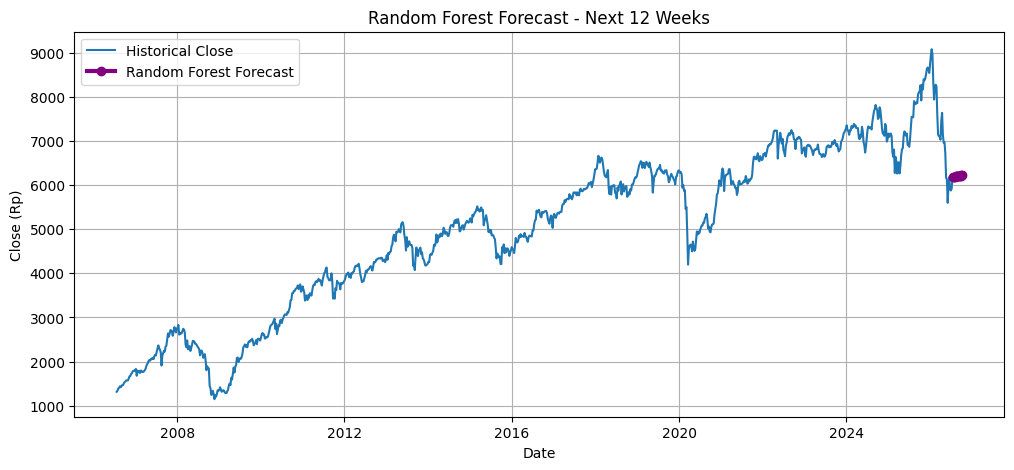

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(weekly_close.index, weekly_close.values, label='Historical Close')
plt.plot(rf_future.index, rf_future.values, marker='o', linewidth=3, label='Random Forest Forecast', color='purple')
plt.title('Random Forest Forecast - Next 12 Weeks')
plt.xlabel('Date')
plt.ylabel('Close (Rp)')
plt.legend()
plt.grid(True)
plt.show()

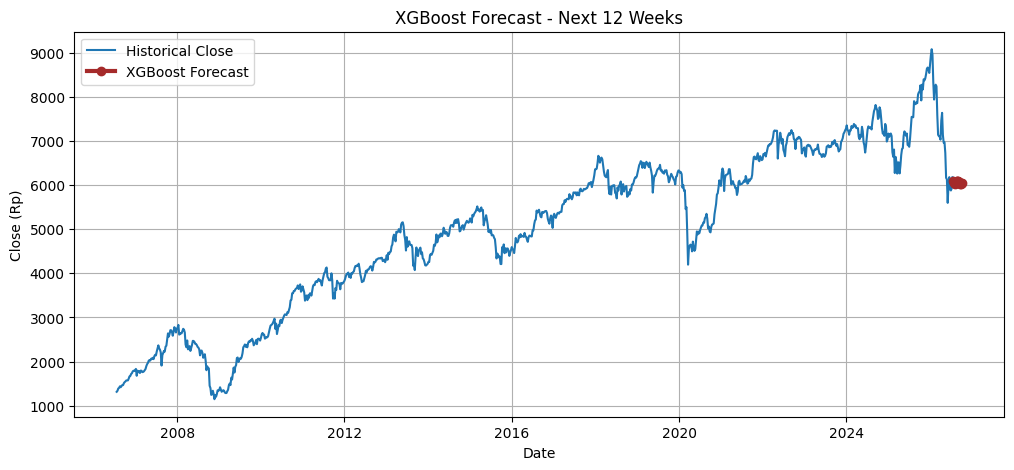

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(weekly_close.index, weekly_close.values, label='Historical Close')
plt.plot(xgb_future.index, xgb_future.values, marker='o', linewidth=3, label='XGBoost Forecast', color='brown')
plt.title('XGBoost Forecast - Next 12 Weeks')
plt.xlabel('Date')
plt.ylabel('Close (Rp)')
plt.legend()
plt.grid(True)
plt.show()

### Perbandingan Forecast Semua Model

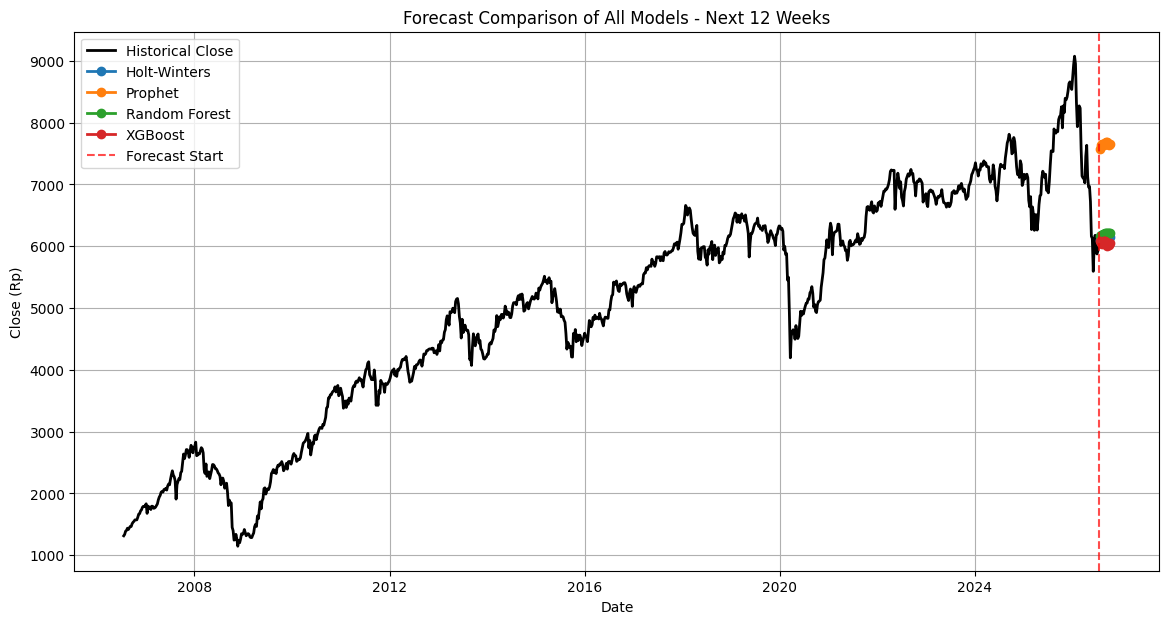

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(weekly_close.index, weekly_close.values, color='black', linewidth=2, label='Historical Close')

plt.plot(hw_future.index, hw_future.values, marker='o', linewidth=2, label='Holt-Winters')
plt.plot(prophet_future.index, prophet_future.values, marker='o', linewidth=2, label='Prophet')
plt.plot(rf_future.index, rf_future.values, marker='o', linewidth=2, label='Random Forest')
plt.plot(xgb_future.index, xgb_future.values, marker='o', linewidth=2, label='XGBoost')

plt.axvline(weekly_close.index[-1], color='red', linestyle='--', alpha=0.7, label='Forecast Start')
plt.title('Forecast Comparison of All Models - Next 12 Weeks')
plt.xlabel('Date')
plt.ylabel('Close (Rp)')
plt.legend()
plt.grid(True)
plt.show()

### Tabel Nilai Prediksi

Nilai forecast numerik untuk tiap model. Kolom terakhir menampilkan angka dari model terbaik (MAPE terendah di tahap evaluasi).

In [ ]:
forecast_table = pd.DataFrame({
    'Holt-Winters': hw_future.values,
    'Prophet': prophet_future.values,
    'Random Forest': rf_future.values,
    'XGBoost': xgb_future.values,
}, index=hw_future.index.strftime('%Y-%m-%d'))

forecast_table.index.name = 'Periode (Minggu, ditutup Jumat)'
forecast_table['Best Model Pick'] = forecast_table[best_model['Model']]
forecast_table

,Holt-Winters,Prophet,Random Forest,XGBoost,Best Model Pick
"Periode (Minggu, ditutup Jumat)",,,,,
2026-07-24,6104.820191,7569.745799,6171.771583,6089.497296,6171.771583
2026-07-31,6095.570426,7642.170308,6177.758542,6050.273410,6177.758542
2026-08-07,6100.879400,7662.108447,6185.298401,6031.507237,6185.298401
2026-08-14,6129.883929,7651.161316,6197.003680,6052.744686,6197.003680
2026-08-21,6104.581165,7643.019613,6200.159268,6081.792580,6200.159268
2026-08-28,6144.011489,7654.783944,6204.341991,6083.967598,6204.341991
2026-09-04,6156.662168,7677.261413,6206.761464,6084.754511,6206.761464
2026-09-11,6204.080925,7689.191087,6209.954399,6067.207345,6209.954399
2026-09-18,6183.377483,7679.358232,6211.721457,6011.253927,6211.721457


## 8. Deployment

Expose model terbaik lewat **FastAPI**

In [ ]:
import joblib

model_lookup = {
    'Random Forest': rf_final,
    'XGBoost': xgb_final,
    'Holt-Winters': hw_final,
    'Prophet': prophet_final,
}

best_model_name = best_model['Model']
best_model_obj = model_lookup[best_model_name]

joblib.dump(best_model_obj, 'model.joblib')
print(f"Model terbaik ({best_model_name}) berhasil disimpan sebagai 'model.joblib'")

Model terbaik (Random Forest) berhasil disimpan sebagai 'model.joblib'


In [ ]:
loaded_model = joblib.load('model.joblib')
loaded_model

RandomForestRegressor(max_depth=8, max_features='sqrt', min_samples_leaf=3,
                      n_estimators=500, random_state=42)